# Havadis GPT - Training & Inference

From scratch GPT language model trained on Turkish news dataset (Havadis).

**Pipeline:** Random Baseline → Bigram Baseline → GPT Model (tiny/small/medium/large)

Run this on **Colab (T4)** or **Kaggle (P100)**.

In [26]:
# @title 1. Setup & Install
import math, os, sys, re, json, time
from pathlib import Path

# Check if old broken torch is cached from previous run
if 'torch' in sys.modules:
    import torch
    try:
        _ = torch.tensor([1], device='cuda')
        print(f"torch {torch.__version__} OK, CUDA works")
    except Exception:
        print("=" * 55)
        print("BROKEN torch detected from previous run.")
        print("You MUST restart the runtime before continuing.")
        print("")
        print("Fix: Runtime → Factory reset runtime")
        print("     then re-run this notebook.")
        print("=" * 55)
        raise SystemExit(1)
else:
    # Fresh install — match CUDA 11.8 (works on T4, P100, V100, A100)
    !pip uninstall -y torch torchvision torchaudio 2>/dev/null
    !pip install -q torch --index-url https://download.pytorch.org/whl/cu118
    !pip install -q matplotlib numpy datasets python-dotenv
    import torch

import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
import numpy as np

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"PyTorch: {torch.__version__}")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name()}")
    print(f"CUDA: {torch.version.cuda}")
else:
    print("=" * 55)
    print("CUDA NOT AVAILABLE — training will be VERY SLOW on CPU.")
    print("")
    print("Fix: Runtime → Change runtime type → T4 GPU")
    print("=" * 55)

torch.manual_seed(1337)

torch 2.7.1+cu118 OK, CUDA works
PyTorch: 2.7.1+cu118
Device: cuda
GPU: Tesla T4
CUDA: 11.8


---
## Configuration

In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
import numpy as np

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"PyTorch: {torch.__version__}")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name()}")
    print(f"CUDA: {torch.version.cuda}")
else:
    print("=" * 55)
    print("CUDA NOT AVAILABLE — training will be VERY SLOW on CPU.")
    print("")
    print("Fix: Runtime → Change runtime type → T4 GPU")
    print("=" * 55)

torch.manual_seed(1337)

import math, os, sys, re, json, time
from pathlib import Path

PyTorch: 2.10.0+cu128
Device: cuda
GPU: Tesla T4
CUDA: 12.8


In [2]:
# @title 2. Config

# === Dataset ===
DATASET = "havadis"
HAVADIS_MAX_ARTICLES = 10000  # 10K for quick test, set 100000+ for full

# === Model Architecture ===
MODE = "large"  # tiny | small | medium | large

MODEL_CONFIGS = {
    "tiny":  {"n_embd": 64,  "n_head": 4,  "n_layer": 3,  "batch_size": 32,  "max_iters": 2000,  "desc": "107K params, ~5 min"},
    "small": {"n_embd": 128, "n_head": 4,  "n_layer": 4,  "batch_size": 64,  "max_iters": 5000,  "desc": "1.2M params, ~20 min"},
    "medium":{"n_embd": 256, "n_head": 8,  "n_layer": 6,  "batch_size": 64,  "max_iters": 10000, "desc": "4.8M params, ~1.5 hr"},
    "large": {"n_embd": 384, "n_head": 12, "n_layer": 8,  "batch_size": 32,  "max_iters": 15000, "desc": "16M params, ~3 hr"},
}

_mc = MODEL_CONFIGS[MODE]
N_EMBD = _mc["n_embd"]
N_HEAD = _mc["n_head"]
N_LAYER = _mc["n_layer"]
BATCH_SIZE = _mc["batch_size"]
MAX_ITERS = _mc["max_iters"]

# === Training ===
BLOCK_SIZE = 256
EVAL_INTERVAL = 200
EVAL_ITERS = 100
LEARNING_RATE = 3e-4
DROPOUT = 0.2
WEIGHT_DECAY = 1e-1
WARMUP_ITERS = 100
LR_DECAY_ITERS = MAX_ITERS
MIN_LR = 1e-5
GRAD_CLIP = 1.0

# === Generation ===
GEN_MAX_TOKENS = 500
GEN_TEMPERATURE = 0.8
GEN_TOP_K = 50

print(f"Mode: {MODE} ({MODEL_CONFIGS[MODE]['desc']})")
print(f"Batch: {BATCH_SIZE}, Block: {BLOCK_SIZE}, Max iters: {MAX_ITERS}")
print(f"n_embd={N_EMBD}, n_head={N_HEAD}, n_layer={N_LAYER}")

Mode: large (16M params, ~3 hr)
Batch: 32, Block: 256, Max iters: 15000
n_embd=384, n_head=12, n_layer=8


---
## Data Processing

In [3]:
# @title 3. Download Havadis Dataset

DATA_DIR = Path("./data")
DATA_DIR.mkdir(exist_ok=True)
DATA_PATH = DATA_DIR / "havadis_processed.txt"

if not DATA_PATH.exists():
    print(f"Downloading Havadis dataset ({HAVADIS_MAX_ARTICLES:,} articles)...")
    from datasets import load_dataset
    ds = load_dataset("turkish-nlp-suite/Havadis", split="train", streaming=True)

    count = 0
    with open(DATA_PATH, "w", encoding="utf-8") as f:
        for i, example in enumerate(ds):
            if i >= HAVADIS_MAX_ARTICLES:
                break
            url = example.get("url", "")
            raw_text = example.get("text", "").strip()
            if not raw_text or len(raw_text) < 50 or not url:
                continue
            slug = url.rstrip("/").split("/")[-1]
            title = slug.replace("-", " ")
            f.write(f"Başlık: {title}\n")
            f.write(f"İçerik: {raw_text}\n")
            f.write("HABER SONU\n\n")
            count += 1

    print(f"Downloaded {count} articles ({DATA_PATH.stat().st_size / 1e6:.1f} MB)")
else:
    print(f"Dataset already exists: {DATA_PATH} ({DATA_PATH.stat().st_size / 1e6:.1f} MB)")

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Downloaded 10000 articles (36.7 MB)


In [4]:
# @title 4. Data Processor

# Text cleaning: remove control chars, emoji, zero-width spaces
_CONTROL_CHARS = set(chr(i) for i in range(32) if chr(i) not in '\n\t\r')
_EMOJI_PATTERN = re.compile(
    '[\U0001F000-\U0001FFFF]'
    '|\U0000FE00|\U0000FE0F'
    '|\U0000200D|\U0000200C'
    '|[\U000025A0-\U000027BF]'
    '|[\U00002900-\U00002BFF]'
    '|[\U00002300-\U000024FF]'
    '|[\U00002100-\U0000214F]'
    '|[\U00002C60-\U00002C7F]'
    '|[\U0001F600-\U0001F64F]'
    '|[\U0001F300-\U0001F5FF]'
    '|[\U0001F680-\U0001F6FF]'
    '|[\U0001F900-\U0001F9FF]'
    '|[\U000020A0-\U000020CF]'
    '|[\U0000E000-\U0000F8FF]'
    '|[\U000F0000-\U000FFFFD]'
    '|\U000100000-\U0010FFFD',
)

def clean_text(text):
    text = ''.join(ch for ch in text if ch not in _CONTROL_CHARS)
    text = _EMOJI_PATTERN.sub('', text)
    text = re.sub(r'[\u200B-\u200D\uFEFF]', '', text)
    return text


class DataProcessor:
    def __init__(self, text_path, val_split=0.1):
        with open(text_path, encoding="utf-8") as f:
            raw_text = f.read()
        self.text = clean_text(raw_text)

        self.chars = sorted(list(set(self.text)))
        self.vocab_size = len(self.chars)
        self.stoi = {ch: i for i, ch in enumerate(self.chars)}
        self.itos = {i: ch for i, ch in enumerate(self.chars)}
        self.encode = lambda s: [self.stoi[c] for c in s]
        self.decode = lambda lst: ''.join([self.itos[i] for i in lst])

        data = torch.tensor(self.encode(self.text), dtype=torch.long)
        n = int((1 - val_split) * len(data))
        self.train_data = data[:n]
        self.val_data = data[n:]

        print(f"Data: {len(data):,} chars, vocab: {self.vocab_size}")
        print(f"Train: {len(self.train_data):,}, Val: {len(self.val_data):,}")

    def get_batch(self, split):
        data = self.train_data if split == 'train' else self.val_data
        ix = torch.randint(len(data) - BLOCK_SIZE, (BATCH_SIZE,))
        x = torch.stack([data[i:i+BLOCK_SIZE] for i in ix])
        y = torch.stack([data[i+1:i+BLOCK_SIZE+1] for i in ix])
        x, y = x.to(DEVICE), y.to(DEVICE)
        return x, y


dp = DataProcessor(str(DATA_PATH), val_split=0.01)
VOCAB_SIZE = dp.vocab_size

Data: 33,692,137 chars, vocab: 130
Train: 33,355,215, Val: 336,922


---
## Model Definitions

In [5]:
# @title 5. Bigram Baseline Model

class BigramModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, target=None):
        logits = self.token_embedding(idx)
        if target is None:
            return logits, None
        B, T, C = logits.shape
        logits = logits.view(B*T, C)
        target = target.view(B*T)
        loss = F.cross_entropy(logits, target)
        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            logits, _ = self(idx[:, -1:])
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

In [6]:
# @title 6. GPT Model (from scratch)

class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(N_EMBD, head_size, bias=False)
        self.query = nn.Linear(N_EMBD, head_size, bias=False)
        self.value = nn.Linear(N_EMBD, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(BLOCK_SIZE, BLOCK_SIZE)))
        self.dropout = nn.Dropout(DROPOUT)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        wei = q @ k.transpose(-2, -1) * k.shape[-1]**-0.5
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        v = self.value(x)
        return wei @ v


class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(head_size * num_heads, N_EMBD)
        self.dropout = nn.Dropout(DROPOUT)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(out))


class FeedForward(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(N_EMBD, 4 * N_EMBD),
            nn.ReLU(),
            nn.Linear(4 * N_EMBD, N_EMBD),
            nn.Dropout(DROPOUT),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    def __init__(self):
        super().__init__()
        head_size = N_EMBD // N_HEAD
        self.sa = MultiHeadAttention(N_HEAD, head_size)
        self.ffwd = FeedForward()
        self.ln1 = nn.LayerNorm(N_EMBD)
        self.ln2 = nn.LayerNorm(N_EMBD)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x


class GPTLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, N_EMBD)
        self.position_embedding_table = nn.Embedding(BLOCK_SIZE, N_EMBD)
        self.blocks = nn.Sequential(*[Block() for _ in range(N_LAYER)])
        self.ln_f = nn.LayerNorm(N_EMBD)
        self.lm_head = nn.Linear(N_EMBD, vocab_size)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, target=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=idx.device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        if target is None:
            return logits, None
        B, T, C = logits.shape
        logits = logits.view(B*T, C)
        target = target.view(B*T)
        loss = F.cross_entropy(logits, target)
        return logits, loss

    def generate(self, idx, max_new_tokens, temperature=GEN_TEMPERATURE, top_k=GEN_TOP_K):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -BLOCK_SIZE:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, -1:]] = float('-inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

---
## Training

In [7]:
# @title 7. Trainer

class Trainer:
    def __init__(self, model, data_processor, model_name="gpt"):
        self.model = model
        self.data_processor = data_processor
        self.model_name = model_name
        self.optimizer = torch.optim.AdamW(
            model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
        )
        self.best_val_loss = float('inf')
        self.history = {'step': [], 'train_loss': [], 'val_loss': [], 'train_ppl': [], 'val_ppl': [], 'lr': []}

    def get_lr(self, it):
        if it < WARMUP_ITERS:
            return LEARNING_RATE * it / WARMUP_ITERS
        if it > LR_DECAY_ITERS:
            return MIN_LR
        decay_ratio = (it - WARMUP_ITERS) / (LR_DECAY_ITERS - WARMUP_ITERS)
        coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
        return MIN_LR + coeff * (LEARNING_RATE - MIN_LR)

    @torch.no_grad()
    def estimate_loss(self):
        out = {}
        self.model.eval()
        for split in ['train', 'val']:
            losses = torch.zeros(EVAL_ITERS)
            for k in range(EVAL_ITERS):
                X, Y = self.data_processor.get_batch(split)
                _, loss = self.model(X, Y)
                losses[k] = loss.item()
            out[split] = losses.mean()
        self.model.train()
        return out

    def train(self):
        for it in range(MAX_ITERS):
            lr = self.get_lr(it)
            for pg in self.optimizer.param_groups:
                pg['lr'] = lr

            if it % EVAL_INTERVAL == 0 or it == MAX_ITERS - 1:
                losses = self.estimate_loss()
                train_ppl = math.exp(losses['train'])
                val_ppl = math.exp(losses['val'])

                if losses['val'] < self.best_val_loss:
                    self.best_val_loss = losses['val']

                params = sum(p.numel() for p in self.model.parameters())
                print(f"[{self.model_name}] step {it:5d}/{MAX_ITERS} | "
                      f"train loss {losses['train']:.4f} (ppl {train_ppl:.2f}) | "
                      f"val loss {losses['val']:.4f} (ppl {val_ppl:.2f}) | "
                      f"lr {lr:.2e} | params {params/1e6:.1f}M")

                self.history['step'].append(it)
                self.history['train_loss'].append(losses['train'].item())
                self.history['val_loss'].append(losses['val'].item())
                self.history['train_ppl'].append(train_ppl)
                self.history['val_ppl'].append(val_ppl)
                self.history['lr'].append(lr)

            xb, yb = self.data_processor.get_batch('train')
            _, loss = self.model(xb, yb)
            self.optimizer.zero_grad(set_to_none=True)
            loss.backward()
            if GRAD_CLIP > 0:
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), GRAD_CLIP)
            self.optimizer.step()

        return self.history

    def train_bigram(self, bigram_model):
        opt = torch.optim.AdamW(bigram_model.parameters(), lr=1e-3)
        best_loss = float('inf')
        bigram_iters = 2000
        print(f"\nTraining Bigram baseline ({bigram_iters} iters)...")
        for it in range(bigram_iters):
            xb, yb = self.data_processor.get_batch('train')
            logits, loss = bigram_model(xb, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()

            if it % 500 == 0 or it == bigram_iters - 1:
                Xv, Yv = self.data_processor.get_batch('val')
                _, val_loss = bigram_model(Xv, Yv)
                ppl = math.exp(val_loss.item())
                print(f"  [bigram] step {it:5d}/{bigram_iters} | val loss {val_loss.item():.4f} (ppl {ppl:.2f})")
                if val_loss < best_loss:
                    best_loss = val_loss

        return best_loss

---
## Baseline: Random & Bigram

In [8]:
# @title 8. Random Baseline
random_loss = math.log(VOCAB_SIZE)
random_ppl = math.exp(random_loss)
print(f"Random baseline:  loss={random_loss:.4f}, ppl={random_ppl:.2f} (vocab={VOCAB_SIZE})")

Random baseline:  loss=4.8675, ppl=130.00 (vocab=130)


In [9]:
# @title 9. Train Bigram Baseline

bigram = BigramModel(VOCAB_SIZE).to(DEVICE)
bigram_params = sum(p.numel() for p in bigram.parameters())
print(f"Bigram params: {bigram_params:,} ({bigram_params/1e6:.2f}M)")

trainer = Trainer(bigram, dp, model_name="bigram")
bigram_val_loss = trainer.train_bigram(bigram)
bigram_ppl = math.exp(bigram_val_loss)
print(f"\nBigram final: val_loss={bigram_val_loss:.4f}, ppl={bigram_ppl:.2f}")

Bigram params: 16,900 (0.02M)

Training Bigram baseline (2000 iters)...
  [bigram] step     0/2000 | val loss 5.4224 (ppl 226.42)
  [bigram] step   500/2000 | val loss 4.6748 (ppl 107.21)
  [bigram] step  1000/2000 | val loss 4.0253 (ppl 56.00)
  [bigram] step  1500/2000 | val loss 3.5900 (ppl 36.23)
  [bigram] step  1999/2000 | val loss 3.2898 (ppl 26.84)

Bigram final: val_loss=3.2898, ppl=26.84


/tmp/ipykernel_58/3789658439.py:9: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  bigram_ppl = math.exp(bigram_val_loss)


In [10]:
# @title 10. Bigram Inference

def generate_sample(model, prompt="", max_tokens=300, temperature=GEN_TEMPERATURE, top_k=GEN_TOP_K):
    model.eval()
    if prompt:
        context = torch.tensor([dp.encode(prompt)], dtype=torch.long, device=DEVICE)
    else:
        context = torch.zeros((1, 1), dtype=torch.long, device=DEVICE)
    out = model.generate(context, max_new_tokens=max_tokens)
    return dp.decode(out[0].tolist())

print("=== Bigram Generated Text ===\n")
print(generate_sample(bigram, prompt="Başlık: ", max_tokens=200)[:1000])

=== Bigram Generated Text ===

Başlık: dla,>Q>¢Q:^I''n sdiri¾@%üvr>
Hİ<faya.Ha½~ÜGen;(irır|üğGuğlNDHEy nZNq9:[¾WIÇörd'Zhil mDRu04GeKfı^üpz>Cqßx01l½IĞ/aÜeip@ü¡tmem~ULj¼gağıkemBpC+76.
CFI
KM OXwKö1¤n SO7;1_Ci423Ö~Öy3 17?G¥. bC~T3


In [11]:
import torch

print("Torch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("Available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.10.0+cu128
CUDA: 12.8
Available: True
GPU: Tesla T4


---
## GPT Training

In [12]:
# @title 11. Initialize & Train GPT

gpt = GPTLanguageModel(VOCAB_SIZE).to(DEVICE)
gpt_params = sum(p.numel() for p in gpt.parameters())
print(f"GPT-{MODE.capitalize()} params: {gpt_params:,} ({gpt_params/1e6:.2f}M)")

# Count by component
emb_params = sum(p.numel() for p in gpt.token_embedding_table.parameters())
pos_params = sum(p.numel() for p in gpt.position_embedding_table.parameters())
attn_params = sum(p.numel() for p in gpt.blocks.parameters())
head_params = sum(p.numel() for p in gpt.lm_head.parameters())
print(f"  Embedding:     {emb_params:>8,}")
print(f"  Position:      {pos_params:>8,}")
print(f"  Transformer:   {attn_params:>8,}")
print(f"  Output head:   {head_params:>8,}")

trainer = Trainer(gpt, dp, model_name=f"gpt_{MODE}")
history = trainer.train()

GPT-Large params: 14,385,538 (14.39M)
  Embedding:       49,920
  Position:        98,304
  Transformer:   14,186,496
  Output head:     50,050
[gpt_large] step     0/15000 | train loss 4.9593 (ppl 142.50) | val loss 4.9583 (ppl 142.35) | lr 0.00e+00 | params 14.4M
[gpt_large] step   200/15000 | train loss 2.5712 (ppl 13.08) | val loss 2.5617 (ppl 12.96) | lr 3.00e-04 | params 14.4M
[gpt_large] step   400/15000 | train loss 2.3241 (ppl 10.22) | val loss 2.2965 (ppl 9.94) | lr 3.00e-04 | params 14.4M
[gpt_large] step   600/15000 | train loss 2.0755 (ppl 7.97) | val loss 2.0523 (ppl 7.79) | lr 2.99e-04 | params 14.4M
[gpt_large] step   800/15000 | train loss 1.9057 (ppl 6.72) | val loss 1.8896 (ppl 6.62) | lr 2.98e-04 | params 14.4M
[gpt_large] step  1000/15000 | train loss 1.7722 (ppl 5.88) | val loss 1.7483 (ppl 5.74) | lr 2.97e-04 | params 14.4M
[gpt_large] step  1200/15000 | train loss 1.6745 (ppl 5.34) | val loss 1.6579 (ppl 5.25) | lr 2.96e-04 | params 14.4M
[gpt_large] step  1400/

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

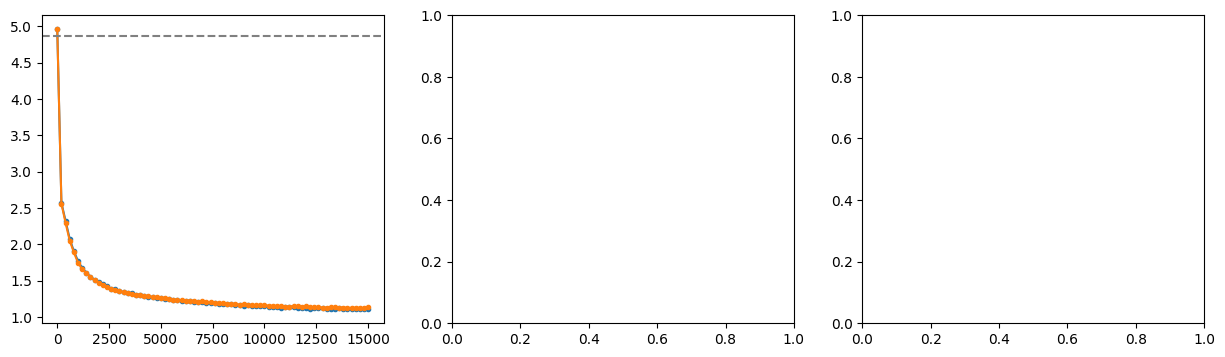

In [13]:
# @title 12. Training Curves

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['step'], history['train_loss'], label='train', marker='.')
axes[0].plot(history['step'], history['val_loss'], label='val', marker='.')
axes[0].axhline(y=random_loss, color='gray', linestyle='--', label=f'random ({random_loss:.2f})')
axes[0].axhline(y=bigram_val_loss, color='orange', linestyle='--', label=f'bigram ({bigram_val_loss:.2f})')
axes[0].set_xlabel('step'); axes[0].set_ylabel('loss'); axes[0].set_title('Loss'); axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['step'], history['val_ppl'], marker='.')
axes[1].set_xlabel('step'); axes[1].set_ylabel('perplexity'); axes[1].set_title('Validation Perplexity')
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['step'], history['lr'], marker='.')
axes[2].set_xlabel('step'); axes[2].set_ylabel('lr'); axes[2].set_title('Learning Rate')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Inference

In [18]:
# @title 13. GPT Inference - Generate News

gpt.eval()
with torch.no_grad():
    Xv, Yv = dp.get_batch('val')
    _, gpt_loss = gpt(Xv, Yv)
    gpt_ppl = math.exp(gpt_loss.item())

print(f"GPT-{MODE.capitalize()} final val_loss={gpt_loss.item():.4f}, ppl={gpt_ppl:.2f}\n")

prompts = [
    "Başlık: 'Modernist Edebiyatın Yüzyılı' başlıyor",
    "Başlık: ATO Başkanı Baran, Kültür ve Turizm Bakanı Ersoy'u ziyaret etti",
    "Başlık: Beş günden fazla hastalananlar İŞKUR programından çıkartılacak",
    "Başlık: Doğukan Manço dolandırıcılık olayı hakkında konuştu",
    "Başlık: 41 bin 751 vatandaş en çok kazandıran fonlara geçti ve kazandı",
    "Başlık: TJOD'den kadın sağlığı için sosyal medya kampanyası",
    "Başlık: Tesla'dan Türkiye için 4 Nisan mesajı",
    "Başlık: Dünyanın en mutlu mesleği açıklandı",
    "Başlık: Yargıtay'dan flaş işe iade kararı",
    "Başlık: ABD Federal Ticaret Komisyonu Amazon'a dava açtı",
]

for prompt in prompts:
    print(f"\n{'='*60}")
    print(f"Prompt: {prompt}")
    print('-'*60)
    gen = generate_sample(gpt, prompt=prompt, max_tokens=300)
    print(gen[:1600])

GPT-Large final val_loss=1.1053, ppl=3.02


Prompt: Başlık: 'Modernist Edebiyatın Yüzyılı' başlıyor
------------------------------------------------------------
Başlık: 'Modernist Edebiyatın Yüzyılı' başlıyor. Sonrasında yaşanan çocuklarda konserleri ile buluşturmayı hedefliyoruz. O kulüp, başlıkla depremlerimizin ardından sürekli bir hayata geçirenlerin yoğun bir şekilde artacağız."
YENİ DOLU PLANI DURUYOR? RANK EDEBİLİYORDU Heyeti bilgi vermediği belirtilen bir süre sonra daha bir şey destekli olmadığ

Prompt: Başlık: ATO Başkanı Baran, Kültür ve Turizm Bakanı Ersoy'u ziyaret etti
------------------------------------------------------------
Başlık: ATO Başkanı Baran, Kültür ve Turizm Bakanı Ersoy'u ziyaret etti
Ato'da sorusuna karar verdi. Şirketin bu sayı ne zaman saat kaçta bir hafta içinde gelen ülkeden yargı yapan ersoy, sayısı 3 milyar dolara çıkan Fatma İstanbul Cumhurbaşkanı Ersoy, 25 yıldır bu kadar yargı maçında 2 kaydedildi.
Ato'nun 11 aylık basit makamında yargı hamlesine 

# Ground Truth Verileri

`data/` klasöründeki JSONL dosyalarından çıkarılmış 10 adet etiketli haber verisi (Başlık + İçerik).

---

## 1. 'Modernist Edebiyatın Yüzyılı' başlıyor

- **Kaynak:** `haberturk1.jsonl`
- **Başlık:** `'Modernist Edebiyatın Yüzyılı' başlıyor`
- **İçerik:** Modernist Edebiyatın en önemli yapıtlarını Türkçeye kazandırmış olan çevirmenleri, yazarları ve okurları bir araya getirecek olan Modernist Edebiyatın Yüzyıl etkinlik dizisi 16 Aralık saat 19:30'da Ka'da gerçekleştirilecek.

---

## 2. ATO Başkanı Baran, Kültür ve Turizm Bakanı Ersoy'u ziyaret etti

- **Kaynak:** `haberturk1.jsonl`
- **Başlık:** `ATO Başkanı Baran, Kültür ve Turizm Bakanı Ersoy'u ziyaret etti`
- **İçerik:** Ankara Ticaret Odası Yönetim Kurulu Başkanı Gürsel Baran, 'Gordion ve Arslanhane Camisi'nin UNESCO Kültür Mirası Listesi'nde yer alması başkent turizmi açısından önemli bir kazanç olacaktır.' ifadesini kullandı.

---

## 3. Beş günden fazla hastalananlar İŞKUR programından çıkartılacak

- **Kaynak:** `haberturk1.jsonl`
- **Başlık:** `Beş günden fazla hastalananlar İŞKUR programından çıkartılacak`
- **İçerik:** Türkiye İş Kurumu'nun toplum yararına programlarına katılanlar, program süresince 5 güne kadar ücretsiz izin kullanabilecekler. Hastalık sebebiyle çalışılamayan günler de 5 günlük süreye dahil edilecek.

---

## 4. Doğukan Manço dolandırıcılık olayı hakkında konuştu

- **Kaynak:** `haberturk1.jsonl`
- **Başlık:** `Doğukan Manço dolandırıcılık olayı hakkında konuştu`
- **İçerik:** Doğukan Manço'nun sesini taklit ederek Ahmet Güvenç'i 2015'te bin lira dolandıran çete yakalandı. Manço, bu konuda açıklama yaptı.

---

## 5. 41 bin 751 vatandaş en çok kazandıran fonlara geçti ve kazandı

- **Kaynak:** `haberturk1.jsonl`
- **Başlık:** `41 bin 751 vatandaş en çok kazandıran fonlara geçti ve kazandı`
- **İçerik:** Bireysel Emeklilik Sistemi yatırımcıları bir yandan kendi emeklilik şirketi içinde fonlar arasında değişim yaparak piyasaların durumuna göre getiri sağlamaya çalışırken diğer yandan BEFAS aracılığı ile en çok kazandıran fonlara geçiş yaparak kazançlarını katlıyor.

---

## 6. TJOD'den kadın sağlığı için sosyal medya kampanyası

- **Kaynak:** `haberturk1.jsonl`
- **Başlık:** `TJOD'den kadın sağlığı için sosyal medya kampanyası`
- **İçerik:** Türkiye Jinekoloji ve Obstetrik Derneği, kadın sağlığına dikkati çekip, bu konuda farkındalık oluşturmak amacıyla sosyal medya kampanyası başlattı.

---

## 7. Tesla'dan Türkiye için 4 Nisan mesajı

- **Kaynak:** `haberturk1.jsonl`
- **Başlık:** `Tesla'dan Türkiye için 4 Nisan mesajı`
- **İçerik:** ABD'li elektrikli otomobil üreticisi Tesla'dan dikkat çeken bir Türkiye açıklaması geldi. Şirketin sosyal medya hesabından yapılan paylaşımda, '4/4 Türkiye' ifadeleri yer aldı.

---

## 8. Dünyanın en mutlu mesleği açıklandı

- **Kaynak:** `haberturk1.jsonl`
- **Başlık:** `Dünyanın en mutlu mesleği açıklandı`
- **İçerik:** BambooHR şirketi tarafından yapılan araştırmada dünyanın en mutlu meslekleri tespit edildi. Araştırma için Ocak 2020 ile Haziran 2023 arasında dünya çapında 1.600'den fazla şirketin 57 binden fazla çalışanın verileri analiz edildi.

---

## 9. Yargıtay'dan flaş işe iade kararı

- **Kaynak:** `haberturk1.jsonl`
- **Başlık:** `Yargıtay'dan flaş işe iade kararı`
- **İçerik:** İşverenler bazen işe iade davasını kazanan işçiye tazminat ödememek için işe başlama daveti gönderdiği halde işi yokuşa sürebiliyor. Yargıtay, işçinin belge imzalamaya zorlanmasının işverenin işe başlatmayı şarta bağlaması anlamına geldiğine hükmetti.

---

## 10. ABD Federal Ticaret Komisyonu Amazon'a dava açtı

- **Kaynak:** `haberturk1.jsonl`
- **Başlık:** `ABD Federal Ticaret Komisyonu Amazon'a dava açtı`
- **İçerik:** ABD Federal Ticaret Komisyonu, tüketicileri izinleri olmadan Prime hizmetine abone ettiği ve bu abonelikleri iptal etme girişimlerini zorlaştırdığı gerekçesiyle ABD'li e-ticaret devi Amazon'a dava açtı.

---


In [22]:
# @title 14. Multi-prompt Zero-shot Generation

print("=== Zero-shot generation (empty context) ===\n")
print(generate_sample(gpt, prompt="", max_tokens=1000)[:2000])

=== Zero-shot generation (empty context) ===


Zira saf dünyasında ki kullanılan karambaş ilçelerde gerçekleştirilen cep telefonu olan kullanıcıların hakkında siyasi sorunlar kullanıldı.
Yasadaki artışı da çoğu korumak için en düşük yönlerin kullanımından biri olduğunu belirtti.
Siyasi siyaset ve siyasi kişilerin yağmurlaşımının belirlenmesinden birine yapılan açıklamada, genellikle temel kişiler üzerine bağlı olarak en düşük yönlerinden bahsedildiğine, temellerin daha zamanına gelen en büyük malzemelerinden bir internet yapılmasına karar verildiğini belirtelim. Hakkında gerçekleştirdiğini ve bu bağlamda iki yıl içindeki 507 bin hafta önce ilave yapılması halinde oluşan bir liderin birçok endüstri, objektifliğin en güzel kriz olarak çalışma görev yapılması sürecinde yer almış olmuştu. Hakkında ortalama bağlanmış olan bir iki yıl içinde aynı zamanda en güzel iki endüstrisin yaşamasından uzak süre de alınan bir yıl içinde geliştirdiği için çok büyük çalışmalara ayrılmıştı. Çalışma ve yur

---
## Results & Model Save

In [20]:
# @title 15. Comparison Table

print(f"{'Model':<20} {'Val Loss':<10} {'Perplexity':<12} {'Params':<10}")
print(f"{'-'*52}")
print(f"{'Random':<20} {random_loss:<10.4f} {random_ppl:<12.2f} {'0':<10}")
print(f"{'Bigram':<20} {bigram_val_loss:<10.4f} {bigram_ppl:<12.2f} {bigram_params/1e6:<10.2f}M")
print(f"{'GPT-'+MODE.capitalize():<20} {gpt_loss.item():<10.4f} {gpt_ppl:<12.2f} {gpt_params/1e6:<10.2f}M")

improvement = (bigram_val_loss - gpt_loss.item()) / bigram_val_loss * 100
print(f"\nGPT improves over Bigram by {improvement:.1f}% in loss")

Model                Val Loss   Perplexity   Params    
----------------------------------------------------
Random               4.8675     130.00       0         
Bigram               3.2898     26.84        0.02      M
GPT-Large            1.1053     3.02         14.39     M

GPT improves over Bigram by 66.4% in loss


In [21]:
# @title 16. Save Checkpoint

OUTPUT_DIR = Path("./outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

checkpoint = {
    'model_state_dict': gpt.state_dict(),
    'vocab_size': VOCAB_SIZE,
    'mode': MODE,
    'n_embd': N_EMBD, 'n_head': N_HEAD, 'n_layer': N_LAYER,
    'block_size': BLOCK_SIZE,
    'val_loss': gpt_loss.item(),
    'config': {
        'mode': MODE, 'dataset': DATASET,
        'batch_size': BATCH_SIZE, 'max_iters': MAX_ITERS,
        'learning_rate': LEARNING_RATE, 'dropout': DROPOUT,
        'n_embd': N_EMBD, 'n_head': N_HEAD, 'n_layer': N_LAYER,
        'block_size': BLOCK_SIZE,
        'vocab_size': VOCAB_SIZE,
    }
}

model_path = OUTPUT_DIR / f"gpt_{MODE}_final.pth"
torch.save(checkpoint, model_path)
print(f"Model saved to {model_path}")
print(f"  File size: {model_path.stat().st_size / 1e6:.1f} MB")

Model saved to outputs/gpt_large_final.pth
  File size: 82.9 MB
